# Commande PID d'un double intégrateur


Ce notebook synthétise et simule un correcteur **PID discret** pour le modèle de **balle sur poutre**.

Le système est un **double intégrateur** : $P(s) = H/s^2$ avec $H \approx 0{,}21\ \text{m\,s}^{-2}/\text{rad}$. Sans amortissement naturel, la boucle fermée est entièrement déterminée par le correcteur.

Deux simulations sont comparées : le modèle discret linéaire (fonctions de transfert) et la dynamique non linéaire continue intégrée par RK4.

In [1]:
from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import LinearStateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel
from Models.BallBeam.NonlinearDynamics import NonlinearBallBeamModel

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridSim
from Simulation.simulation import NonLinearHybridSim

from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting
from Metrics_Plotting.Metrics import Metrics

from Control.DiscretePID import DiscretePID
from Control.RSTController import RSTController

from Utils import computeRST
from Utils import utils

import numpy as np
import control as ct
import matplotlib.pyplot as plt

%matplotlib inline

Configuration de la simulation:


T est le temps total de simulation et dt est le temps d'échantillonage du correcteur

In [2]:
ballbeam_config.T=6
ballbeam_config.dt=0.05

In [3]:
X_0 = np.array([[0.0],[0]])                              # état initial
double_int = TransferFunctionModel(ballbeam_config)    # instance de TransferFunctionModel
double_int_NL =NonlinearBallBeamModel(ballbeam_config)# pour la simulation hybride non lineaire
double_int_simNL=NonLinearHybridSim(double_int_NL,ballbeam_config)
Double_int_sim = TFSimulator(double_int.Tf_dis, X_0)   # simulateur de fonctions de transfert discrètes
A = double_int.Tf_dis.den_list[0][0]                   # extraction du dénominateur A(z)
B = double_int.Tf_dis.num_list[0][0]                   # extraction du numérateur B(z)

In [4]:
### affichage 
print(double_int.Tf_cont)
print(double_int.Tf_dis)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.21
  ----
  s^2
<TransferFunction>: sys[0]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0002625 z + 0.0002625
  -----------------------
       z^2 - 2 z + 1


### Choix des gains PID


> **Pourquoi $K_i = 0$ ?**  
> L'erreur statique sur un échelon de consigne, dans le cas d'un double integrateur, est nulle sans action intégrale. Ajouter $K_i \neq 0$ crée une boucle avec trois pôles à $z = 1$ en boucle ouverte, très difficile à stabiliser.  
> **Contrepartie :** une perturbation d'entrée constante $D$ laisse une erreur statique permanente $e_\infty = D/K_p$.

In [5]:
kp = 43
ki = 0 # sans action intégrale : erreur statique non nulle face à une perturbation constante
kd = 21

Synthèse du correcteur PID:
Ici, nous ajoutons un filtre de l'action dérivée avec le mot-clé "filtered"

In [6]:
PID_controller=DiscretePID(kp,ki,kd,ballbeam_config.dt,"filtered")

In [7]:
L = PID_controller.transferFunction * double_int.Tf_dis
T_cl = ct.feedback(L, 1)
print(T_cl)
print("DC gain:       ", T_cl.dcgain())
cl_poles = np.roots(T_cl.den_list[0][0])
print("Closed-loop poles (z):", cl_poles)
print("Pole radii:           ", np.abs(cl_poles))

<TransferFunction>: sys[12]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

     0.3151 z^2 + 0.02822 z - 0.2869
  -------------------------------------
  3.5 z^3 - 7.685 z^2 + 5.528 z - 1.287
DC gain:        0.9999999999999921
Closed-loop poles (z): [0.84029928+0.08802537j 0.84029928-0.08802537j 0.51507823+0.j        ]
Pole radii:            [0.84489724 0.84489724 0.51507823]


### Marges de stabilité

Les marges de gain et de phase quantifient la robustesse de la boucle fermée. Les cibles habituelles sont $\text{MG} > 6\ \text{dB}$ et $\text{MP} > 45°$.



In [8]:
Performance_Stabilite=Metrics()
Performance_Stabilite.Stability(L)

Gain margin:   17.6 dB  (×7.57)
Phase margin:  49.6°


### Simulation
On utilise le simulateur discret. Le premier True/False détermine la présence d'une perturbation constante au bout de la troisième seconde. Le deuxième active (si True) la saturation de l'actionneur.

In [9]:
logger_PID = SimLog()

reference = 0.25
y_0 = 0.0

logger_PID = run_discrete_control(Double_int_sim, PID_controller, ballbeam_config, reference, y_0, logger_PID, True, True)

### Métriques de performance

Dépassement, temps de montée (10 %→90 %) et temps d'établissement (bande ±10 %) calculés sur la phase de suivi de consigne (avant $t=3s$).

Le dépassement observé peut etre supérieur à la cible théorique en raison de la saturation de l'actionneur en début de réponse : le signal $u(t)$ est borne entre  ±10 rad.

In [10]:
Performance_Stabilite.response_data(logger_PID,reference,)

Dépassement :          0.7 %
Temps de montée :      0.650 s  (10 %→90 %)
Temps d'établissement :     0.800 s  (bande ±10 %)


### Rejet de perturbation

La fonction de transfert **perturbation → sortie** est :

$$G_d(z) = \frac{B(z)\,S(z)}{A(z)\,S(z) + B(z)\,R(z)}$$

Son gain DC évalue la déviation permanente causée par une perturbation constante $D=2.0 [rad]$.

> **Note numérique :** `ct.dcgain` renvoie 0,0 ici car $A(1) = 0$ (double intégrateur) force une indétermination $0/0$ dans l'évaluation polynomiale. La réponse indicielle de $G_d$ (tracée ci-dessous) donne la vraie valeur : l'erreur statique converge vers $e_\infty \approx D/K_p$.

**Contraste avec le RST** : le correcteur RST avec `Integrator=True` force $S(1) = 0$, ce qui annule rigoureusement le gain DC de $G_d$ et supprime toute erreur statique de perturbation.

In [11]:
A_arr = np.squeeze(A)
B_arr = np.squeeze(B)
R_arr = np.squeeze(PID_controller.R.num[0][0])
S_arr = np.squeeze(PID_controller.S.num[0][0])

num_d = np.polymul(B_arr, S_arr)
den_d = np.polyadd(np.polymul(A_arr, S_arr), np.polymul(B_arr, R_arr))

Gd = ct.tf(num_d, den_d, ballbeam_config.dt)
print(Gd)
print("DC gain Gd:", ct.dcgain(Gd))

t = np.arange(0, ballbeam_config.T, ballbeam_config.dt)
t = np.asarray(t).flatten()
_, d_resp = ct.step_response(Gd, t)
d_resp = np.squeeze(d_resp)

<TransferFunction>: sys[13]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0009187 z^2 + 0.0006563 z - 0.0002625
  ---------------------------------------
   3.5 z^3 - 7.685 z^2 + 5.528 z - 1.287
DC gain Gd: 0.023255813953488188


Affichage des trois réponses

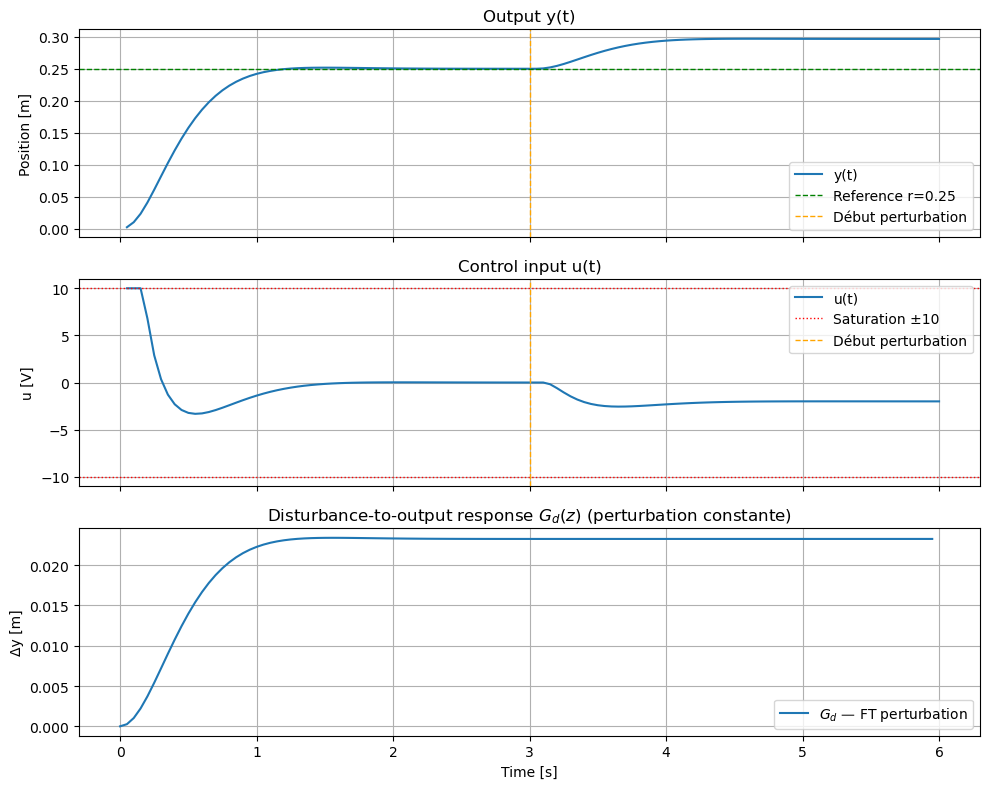

In [12]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(logger_PID.t_hist, logger_PID.y_hist, label='y(t)')
ax[0].axhline(y=reference, color='green', linestyle='--', linewidth=1, label=f'Reference r={reference}')
ax[0].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Début perturbation')
ax[0].set_title("Output y(t)")
ax[0].set_ylabel("Position [m]")
ax[0].legend()
ax[0].grid()

ax[1].plot(logger_PID.t_hist, logger_PID.u_hist, label='u(t)')
ax[1].axhline(y= 10, color='red', linestyle=':', linewidth=1, label='Saturation ±10')
ax[1].axhline(y=-10, color='red', linestyle=':', linewidth=1)
ax[1].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Début perturbation')
ax[1].set_title("Control input u(t)")
ax[1].set_ylabel("u [V]")
ax[1].legend()
ax[1].grid()

ax[2].plot(t, d_resp, label='$G_d$ — FT perturbation')
ax[2].set_title("Disturbance-to-output response $G_d(z)$ (perturbation constante)")
ax[2].set_ylabel("Δy [m]")
ax[2].set_xlabel("Time [s]")
ax[2].legend()
ax[2].grid()

plt.tight_layout()
plt.show()


## Simulation non linéaire

Le simulateur linéaire ci-dessus utilise la fonction de transfert discrète exacte du procédé. Ici on remplace le procédé par la **dynamique non linéaire** de la balle sur poutre, intégrée par RK4 à $dt_\text{plant} = 1\ \text{ms}$, le correcteur étant mis à jour toutes les $dt = 50\ \text{ms}$ (maintien d'ordre zéro).

Différences attendues par rapport à la simulation linéaire :
- La saturation de $u$ a un effet plus prononcé car la dynamique est plus rapide au démarrage.
- Les non-linéarités du sinus ($\sin\alpha \approx \alpha$ n'est exact qu'à petits angles) peuvent introduire un décalage sur le point d'équilibre ou un léger dépassement supplémentaire.
- En pratique, pour une consigne raisonnable ($|r| \lesssim 0{,}3\ \text{m}$), les deux simulations restent proches.

In [13]:
logger_NL=SimLog()
logger_NL=run_continuous_control_loop(double_int_simNL,PID_controller,reference,X_0,logger_NL,True,True)

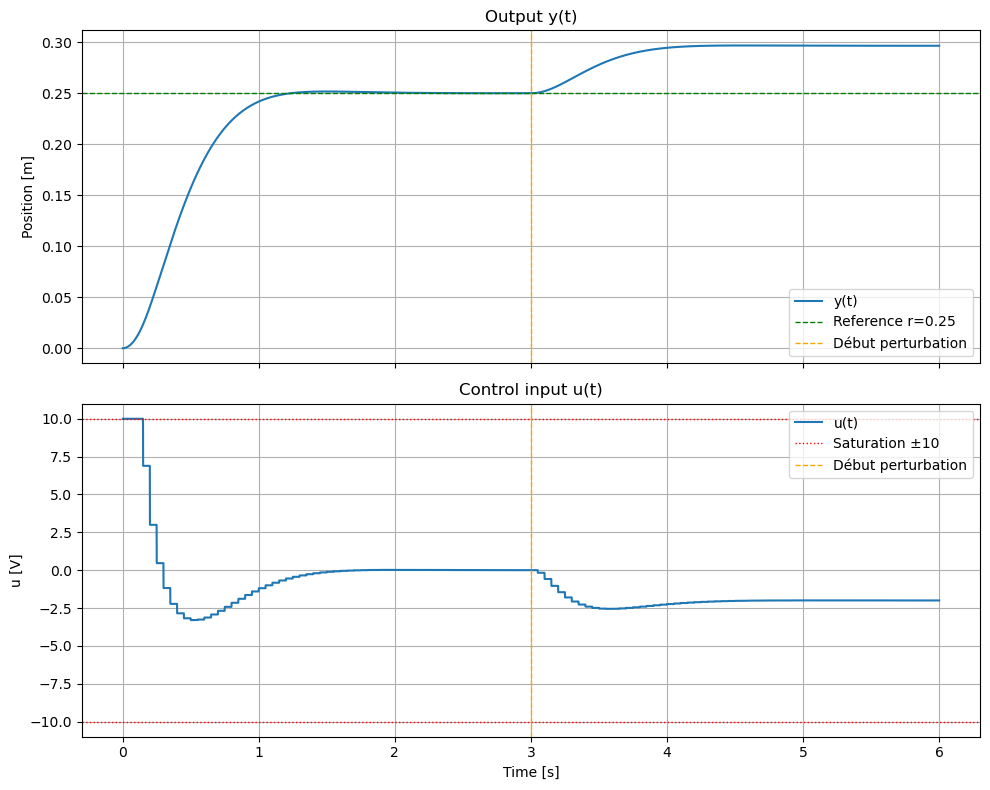

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax[0].plot(logger_NL.t_hist, logger_NL.y_hist, label='y(t)')
ax[0].axhline(y=reference, color='green', linestyle='--', linewidth=1, label=f'Reference r={reference}')
ax[0].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Début perturbation')
ax[0].set_title("Output y(t)")
ax[0].set_ylabel("Position [m]")
ax[0].legend()
ax[0].grid()

ax[1].plot(logger_NL.t_hist, logger_NL.u_hist, label='u(t)')
ax[1].axhline(y= 10, color='red', linestyle=':', linewidth=1, label='Saturation ±10')
ax[1].axhline(y=-10, color='red', linestyle=':', linewidth=1)
ax[1].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Début perturbation')
ax[1].set_title("Control input u(t)")
ax[1].set_ylabel("u [V]")
ax[1].set_xlabel("Time [s]")
ax[1].legend()
ax[1].grid()


plt.tight_layout()
plt.show()
